In [35]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore")

In [36]:
df = pd.read_csv("fraudTest.csv")

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [37]:
print(df.shape)

df.info()

df.describe()

(555719, 23)
<class 'pandas.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  str    
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  str    
 4   category               555719 non-null  str    
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  str    
 7   last                   555719 non-null  str    
 8   gender                 555719 non-null  str    
 9   street                 555719 non-null  str    
 10  city                   555719 non-null  str    
 11  state                  555719 non-null  str    
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [38]:
print(df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [39]:
drop_columns = [
'Unnamed: 0',
'trans_date_trans_time',
'cc_num',
'first',
'last',
'street',
'city',
'state',
'zip',
'lat',
'long',
'job',
'dob',
'trans_num',
'unix_time',
'merch_lat',
'merch_long'
]

df = df.drop(columns=drop_columns)

df.head()

,merchant,category,amt,gender,city_pop,is_fraud
0,fraud_Kirlin and Sons,personal_care,2.86,M,333497,0
1,fraud_Sporer-Keebler,personal_care,29.84,F,302,0
2,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,34496,0
3,fraud_Haley Group,misc_pos,60.05,M,54767,0
4,fraud_Johnston-Casper,travel,3.19,M,1126,0


In [40]:
from sklearn.preprocessing import LabelEncoder

for col in ['merchant', 'category', 'gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [45]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print(X.shape)
print(y.shape)

(555719, 5)
(555719,)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (444575, 5)
Testing Data : (111144, 5)


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy : 0.9958972144245304
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.00      0.00      0.00       429

    accuracy                           1.00    111144
   macro avg       0.50      0.50      0.50    111144
weighted avg       0.99      1.00      0.99    111144



In [49]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy : 0.9965810120204419
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.55      0.60      0.57       429

    accuracy                           1.00    111144
   macro avg       0.78      0.80      0.79    111144
weighted avg       1.00      1.00      1.00    111144



In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy : 0.9978406391708055
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.79      0.60      0.68       429

    accuracy                           1.00    111144
   macro avg       0.90      0.80      0.84    111144
weighted avg       1.00      1.00      1.00    111144



In [51]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.995897
1        Decision Tree  0.996581
2        Random Forest  0.997841


In [52]:
best_model = results.sort_values(by="Accuracy", ascending=False)

print(best_model)

                 Model  Accuracy
2        Random Forest  0.997841
1        Decision Tree  0.996581
0  Logistic Regression  0.995897


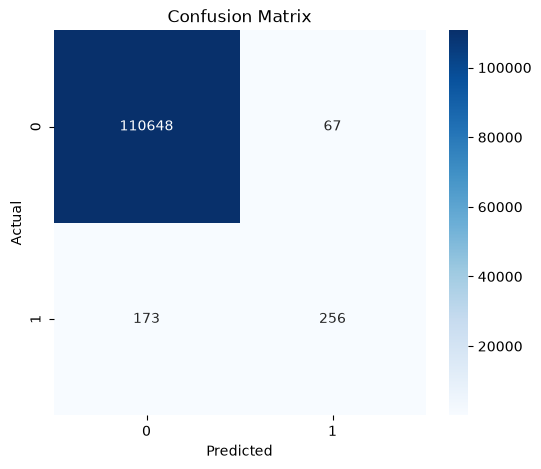

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [54]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

    Feature  Importance
2       amt    0.498836
1  category    0.212702
4  city_pop    0.159714
0  merchant    0.114050
3    gender    0.014698


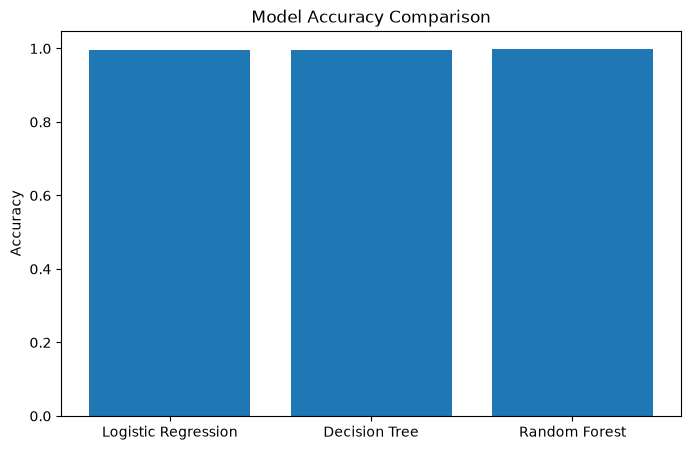

In [55]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracy = [
    lr_acc,
    dt_acc,
    rf_acc
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [56]:
import joblib

joblib.dump(rf, "fraud_detection_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [57]:
model = joblib.load("fraud_detection_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [58]:
sample = X_test[:5]

prediction = model.predict(sample)

print("Prediction :", prediction)

Prediction : [0 0 0 0 0]


In [59]:
comparison = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": prediction
})

print(comparison)

   Actual  Predicted
0       0          0
1       0          0
2       0          0
3       0          0
4       0          0
